In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("/content/Social_media_impact_on_life.csv")

In [7]:
df.head(4)

,Student_ID,Age,Gender,Academic_Level,Primary_Platform,Daily_Usage_Hours,Weekend_Extra_Hours,Device_Type,Sleep_Duration_Hours,Sleep_Quality_Score,Late_Night_Usage,Social_Comparison_Frequency,Perceived_Stress_Score,Mental_Health_Index,Academic_Performance_GPA,Overall_Impact
0,STU_2024000,19,Female,Undergraduate,Snapchat,7.5,1.5,Smartphone,5.9,2,True,Always,20.0,73,2.73,Neutral
1,STU_2024001,19,Female,Undergraduate,Instagram,4.6,1.3,Smartphone,7.9,3,True,Sometimes,17.0,90,3.21,Beneficial
2,STU_2024002,17,Female,High School,TikTok,10.9,1.7,Smartphone,5.2,1,True,Frequently,18.0,70,3.00,Neutral
3,STU_2024003,16,Female,High School,YouTube,6.0,2.3,Tablet,7.6,4,True,Sometimes,15.0,82,3.42,Beneficial


## Insight 1: Gender x Sleep Duration

In [8]:
# Calculate average sleep duration grouped by gender
df.groupby("Gender")["Sleep_Duration_Hours"].mean()

,Sleep_Duration_Hours
Gender,
Female,6.689749
Male,6.719356
Non-Binary,6.662295
Prefer not to say,6.633333


The difference in sleep duration between genders was less than 6 minutes,
suggesting that gender is not a relevant factor for sleep in this dataset.

## Insight 2: Primary Platform x Low Academic Performance

In [9]:
# Check the distribution of the GPA column to define a data-driven cutoff for "low performance"
df["Academic_Performance_GPA"].describe()

,Academic_Performance_GPA
count,4415.000000
mean,3.429282
std,0.392662
min,1.900000
25%,3.200000
50%,3.460000
75%,3.720000
max,4.000000


In [10]:
# Filter students with GPA below 3 (below the 25th percentile)
low_performance = df[df["Academic_Performance_GPA"] < 3]

# Check which platform is most used within this group
low_performance["Primary_Platform"].value_counts()

,count
Primary_Platform,
Instagram,210
TikTok,157
YouTube,112
Snapchat,69
Reddit,34
X (Twitter),27
LinkedIn,7


In [11]:
# Compare with the overall platform distribution to check if Instagram's
# dominance is specific to the low-performance group or just the general pattern
df["Primary_Platform"].value_counts()

,count
Primary_Platform,
Instagram,1453
TikTok,1226
YouTube,818
Snapchat,472
Reddit,229
X (Twitter),206
LinkedIn,96


Among students with low academic performance (GPA < 3), Instagram was the most
used platform. However, when compared to the overall platform distribution among
ALL students, Instagram is also the most used platform in general — meaning this
predominance is not exclusive to the low-performance group.

Conclusion: it is not possible to affirm, based on this isolated data, that there
is a strong relationship between using Instagram and having low academic performance.
The most popular platform simply reflects the overall behavior of the sample, not a
causal association.

## Insight 3: Device Type x High Perceived Stress

In [12]:
# Check the distribution of the stress score to define a data-driven cutoff for "high stress"
df["Perceived_Stress_Score"].describe()

,Perceived_Stress_Score
count,4454.000000
mean,13.512124
std,7.072859
min,0.000000
25%,9.000000
50%,13.000000
75%,18.000000
max,40.000000


In [13]:
# Filter students with stress score above 18 (above the 75th percentile)
high_stress = df[df["Perceived_Stress_Score"] > 18]

# Check which device is most used within this group
high_stress["Device_Type"].value_counts()

,count
Device_Type,
Smartphone,807
Laptop/PC,127
Tablet,16


In [14]:
# Compare proportions (not raw counts) between the high-stress group and the general population
df["Device_Type"].value_counts(normalize=True)
high_stress["Device_Type"].value_counts(normalize=True)

,proportion
Device_Type,
Smartphone,0.849474
Laptop/PC,0.133684
Tablet,0.016842


Smartphone is the most used device both in the high-stress group (84.9%) and in
the general student population (83.9%) — a difference of only 1 percentage point.
This indicates that Smartphone predominance is not specifically associated with
higher stress; it is simply the most used device by everyone, regardless of stress level.

## Insight 4: Late Night Usage x Sleep and Stress

In [26]:
# Check the unique values in the Late_Night_Usage column
df["Late_Night_Usage"].unique()

array([ True, False])

In [27]:
# Compare average sleep duration and stress score between students
# who use social media late at night and those who don't
df.groupby("Late_Night_Usage")[["Sleep_Duration_Hours", "Perceived_Stress_Score"]].mean()

,Sleep_Duration_Hours,Perceived_Stress_Score
Late_Night_Usage,,
False,7.085884,11.162955
True,6.431392,15.167241


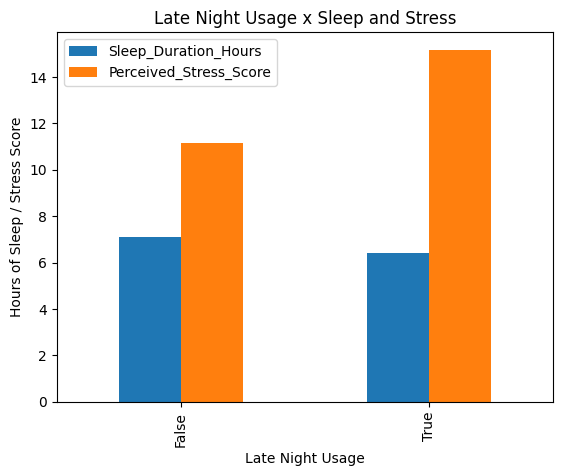

In [28]:
# Visualize the comparison as a bar chart
df.groupby("Late_Night_Usage")[["Sleep_Duration_Hours", "Perceived_Stress_Score"]].mean().plot(kind="bar")
plt.title("Late Night Usage x Sleep and Stress")
plt.xlabel("Late Night Usage")
plt.ylabel("Hours of Sleep / Stress Score")
plt.show()

Students who use social media late at night show, on average, almost 40 minutes
less sleep (6.43h vs 7.09h) and considerably higher perceived stress (15.17 vs
11.16) compared to those who don't. This is the strongest association found so
far in the dataset, well above the differences observed in previous analyses
(gender, platform, device).

It's important to highlight that this data shows a correlation, not a proven
cause-and-effect relationship. There are plausible hypotheses in both directions:
late-night usage may harm sleep and increase stress, but it's also possible that
already more stressed students have difficulty sleeping and, being awake, end up
using more social media at night. The available data doesn't allow us to
distinguish which of these explanations (or a combination of them) is correct.

## Insight 5: Age x Daily Usage Hours

In [18]:
# Check the correlation between age and daily usage hours
df["Age"].corr(df["Daily_Usage_Hours"])

np.float64(-0.029603100131808516)

The correlation between age and daily usage hours is only -0.03, a value
extremely close to zero. This indicates that there is no relevant relationship
between these two variables in this dataset — a student's age does not seem to
influence how much time they spend on social media per day.

## Insight 6: Overall Correlation Between Numeric Variables

In [19]:
# Calculate the correlation matrix between all numeric columns
df.corr(numeric_only=True)

,Age,Daily_Usage_Hours,Weekend_Extra_Hours,Sleep_Duration_Hours,Sleep_Quality_Score,Late_Night_Usage,Perceived_Stress_Score,Mental_Health_Index,Academic_Performance_GPA
Age,1.000000,-0.029603,0.002918,0.012631,0.030933,-0.012673,-0.020696,0.022555,0.028110
Daily_Usage_Hours,-0.029603,1.000000,-0.009572,-0.715903,-0.681290,0.333953,0.754470,-0.849908,-0.710057
Weekend_Extra_Hours,0.002918,-0.009572,1.000000,0.016668,0.012124,0.000286,0.001198,0.004026,0.012275
Sleep_Duration_Hours,0.012631,-0.715903,0.016668,1.000000,0.747737,-0.270778,-0.661657,0.774220,0.595263
Sleep_Quality_Score,0.030933,-0.681290,0.012124,0.747737,1.000000,-0.272493,-0.576453,0.662423,0.529270
Late_Night_Usage,-0.012673,0.333953,0.000286,-0.270778,-0.272493,1.000000,0.278821,-0.299629,-0.254134
Perceived_Stress_Score,-0.020696,0.754470,0.001198,-0.661657,-0.576453,0.278821,1.000000,-0.773744,-0.650921
Mental_Health_Index,0.022555,-0.849908,0.004026,0.774220,0.662423,-0.299629,-0.773744,1.000000,0.659419
Academic_Performance_GPA,0.028110,-0.710057,0.012275,0.595263,0.529270,-0.254134,-0.650921,0.659419,1.000000


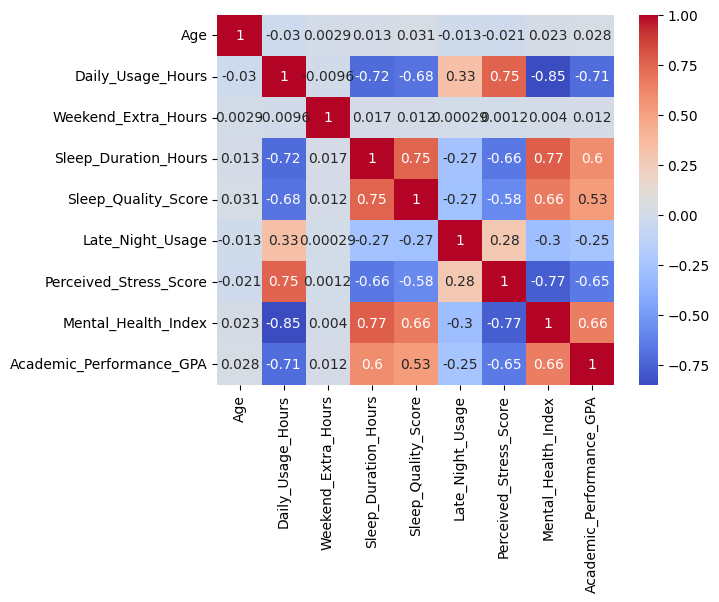

In [20]:
# Visualize the correlation matrix as a heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

The correlation analysis revealed that Daily_Usage_Hours is the variable with
the strongest associations in the dataset, all surpassing what was found in any
other analysis in this project:

- Mental_Health_Index: -0.85 (strong negative association)
- Perceived_Stress_Score: 0.75 (strong positive association)
- Sleep_Duration_Hours: -0.72 (strong negative association)
- Academic_Performance_GPA: -0.71 (strong negative association)

In summary: the higher the number of daily social media usage hours, the worse
the mental health index tends to be, the higher the perceived stress, the shorter
the sleep duration, and the lower the academic performance.

Although these four relationships are the strongest identified in the entire
project, it's important to reinforce that correlation does not imply causation.
The data does not allow us to affirm that social media use is the direct cause
of these problems — there may be inverse explanations (e.g., already stressed
people use more social media as an escape) or other factors not captured in the
dataset that simultaneously influence these variables.

## Insight 7: Social Comparison Frequency x Mental Health


In [22]:
df["Social_Comparison_Frequency"].unique()


array(['Always', 'Sometimes', 'Frequently', 'Never', 'Rarely'],
      dtype=object)

In [24]:
df.groupby("Social_Comparison_Frequency")["Mental_Health_Index"].mean()

,Mental_Health_Index
Social_Comparison_Frequency,
Always,79.893987
Frequently,79.943910
Never,80.519231
Rarely,79.408616
Sometimes,79.927227



The average Mental Health Index ranges only from 79.4 to 80.5 across all
social comparison frequency categories (from "Never" to "Always") — a
difference of just about 1 point on a 0-100 scale. This suggests a weak,
practically negligible relationship between how often students compare
themselves to others on social media and their mental health index in
this dataset.

This is a bit unexpected, since social comparison is commonly assumed to
be a strong driver of poor mental health in social media research. Here,
the data does not support that assumption with any meaningful strength —
unlike Daily_Usage_Hours, which showed a much stronger association (-0.85)
with the same mental health measure.

## Insight 8: Academic Level x Daily Usage Hours


In [25]:
df.groupby("Academic_Level")["Daily_Usage_Hours"].mean()

,Daily_Usage_Hours
Academic_Level,
High School,5.326879
Postgraduate,5.139837
Undergraduate,5.293302


The difference in daily usage hours across academic levels is minimal —
ranging from 5.14 (Postgraduate) to 5.33 (High School) hours, less than
12 minutes of difference. This suggests academic level is not a meaningful
factor in predicting daily social media usage.

## Overall Conclusion

This analysis explored how social media usage relates to students' well-being,
covering sleep, stress, academic performance, mental health, and social
comparison behavior, based on a dataset of student behavior and social media habits.

The most significant finding was that Daily_Usage_Hours (daily time spent on
social media) shows strong associations with multiple well-being indicators:
worse mental health index (-0.85), higher perceived stress (0.75), shorter
sleep duration (-0.72), and lower academic performance (-0.71). Late-night
usage specifically was also linked to nearly 40 minutes less sleep and
noticeably higher stress levels.

In contrast, demographic and behavioral factors — gender, age, social comparison
frequency, and academic level — showed virtually no relationship with these
outcomes, and apparent patterns around platform choice and device type turned
out to simply reflect the overall population distribution rather than meaningful
associations. Notably, social comparison frequency is commonly assumed to
strongly affect mental health, but the data did not support that assumption
here — suggesting that the amount of time spent on social media matters more
than how often users compare themselves to others.

It's important to note that these findings represent correlations, not proven
causal relationships — the data doesn't allow us to determine whether heavy
social media use causes these outcomes, or whether students already struggling
with stress, poor sleep, or academic difficulties turn to social media more as
a result. Future analysis with longitudinal data would be needed to better
understand this direction.

Based on these results, the clearest actionable takeaway is that the *amount*
of daily usage — rather than which platform, device is used, or how often
students compare themselves to others — appears to be the factor most worth
paying attention to when thinking about students' well-being.